# Patient Health Risk Prediction using Machine Learning
This notebook presents an end-to-end healthcare machine learning workflow including data preprocessing, exploratory data analysis (EDA), model development, evaluation, and deployment-ready prediction pipeline.

## Project Objective
The objective of this project is to predict whether a patient belongs to a high health-risk category based on basic physical parameters such as age, weight, and height.

## Dataset Description
The dataset contains patient demographic and physical health measurements including BMI, weight, height, and birthdate information used to derive predictive insights.

## Data Preprocessing
Missing values were handled, incorrect data types were corrected, and birthdate was converted into patient age to improve model usability.

## Exploratory Data Analysis (EDA)
EDA was performed using distribution plots, correlation analysis, and pairplots to understand relationships among variables.

## Key Insights
- Approximately one-third of patients fall under high health risk.
- Weight shows strong correlation with BMI.
- Height shows comparatively weak correlation with BMI.
- Obesity risk is present across multiple age groups.
- Basic measurements enable effective health-risk prediction.

## Outlier Detection
Outliers were examined using boxplots and statistical analysis to detect abnormal patient measurements.

## Machine Learning Model
Logistic Regression was used as the classification model due to its interpretability and suitability for healthcare applications.

## Model Evaluation
Model performance was evaluated using Accuracy, Confusion Matrix, Precision, Recall, and F1-score.

## ML Pipeline
A Scikit-learn pipeline was implemented combining StandardScaler and LogisticRegression for consistent preprocessing and prediction.

## Prediction System
A prediction function allows users to input age, weight, and height to determine patient health risk.

## Conclusion
The project demonstrates a complete machine learning workflow from data analysis to deployment-ready prediction, supporting early healthcare risk screening.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"D:\patients.csv")

In [4]:
df.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [18]:
df.tail()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [6]:
df.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [7]:
df.isnull().sum()

patient_id       0
assigned_sex     0
given_name       0
surname          0
address         12
city            12
state           12
zip_code        12
country         12
contact         12
birthdate        0
weight           0
height           0
bmi              0
dtype: int64

In [8]:
df = df.dropna(subset=['zip_code','country','contact','state','city'])

In [9]:
df.isnull().sum()


patient_id      0
assigned_sex    0
given_name      0
surname         0
address         0
city            0
state           0
zip_code        0
country         0
contact         0
birthdate       0
weight          0
height          0
bmi             0
dtype: int64

(convert zip column int to float

In [10]:
df['zip_code'] = df['zip_code'].astype(int).astype(str)

convert birthdate column to datetime formate

In [11]:
df['birthdate'] = pd.to_datetime(df['birthdate'])

today = pd.Timestamp.today()
df['age'] = (today - df['birthdate']).dt.days // 365

In [12]:
df['bmi'].mean()

np.float64(27.460285132382893)

In [13]:
df['age'].mean()

np.float64(66.83299389002036)

In [14]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['bmi_category'] = df['bmi'].apply(bmi_category)

In [15]:
df['bmi_category'].value_counts()

bmi_category
Normal         176
Obese          172
Overweight     134
Underweight      9
Name: count, dtype: int64

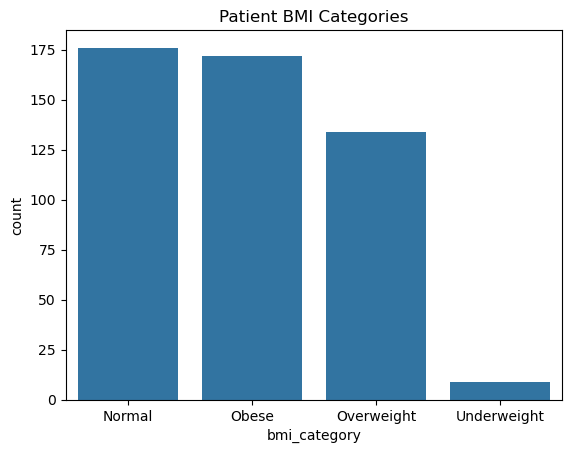

In [16]:
sns.countplot(x='bmi_category', data=df)
plt.title("Patient BMI Categories")
plt.show()

In [17]:
df.shape[0]

491

In [18]:
df['assigned_sex'].value_counts()

assigned_sex
male      248
female    243
Name: count, dtype: int64

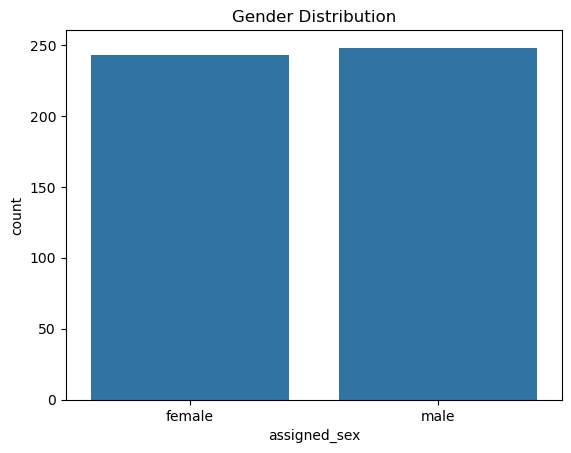

In [19]:
sns.countplot(x='assigned_sex', data=df)
plt.title("Gender Distribution")
plt.show()

In [20]:
def age_group(age):
    if age < 18:
        return "Child"
    elif age < 35:
        return "Young Adult"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df['age_group'] = df['age'].apply(age_group)

In [21]:
df['age_group'].value_counts()

age_group
Senior         290
Adult          158
Young Adult     43
Name: count, dtype: int64

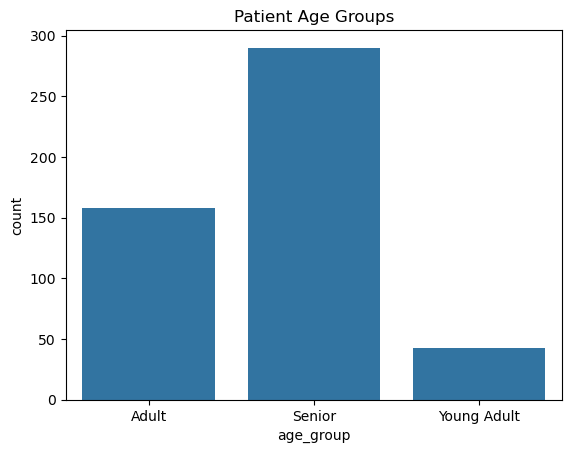

In [22]:
sns.countplot(x='age_group', data=df)
plt.title("Patient Age Groups")
plt.show()

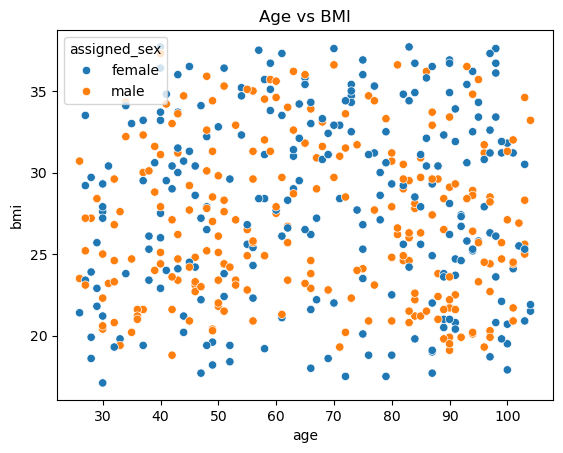

In [23]:
sns.scatterplot(x='age', y='bmi', hue='assigned_sex', data=df)
plt.title("Age vs BMI")
plt.show()

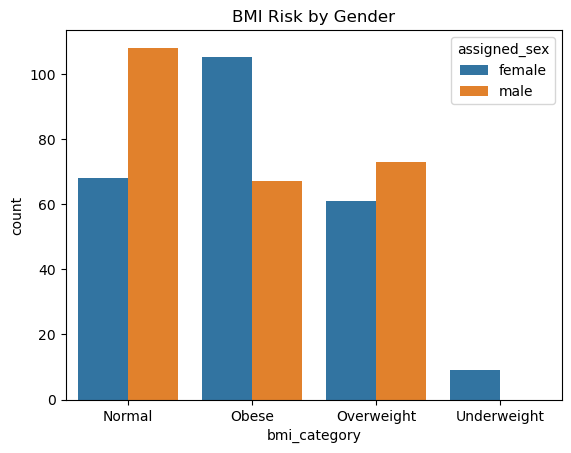

In [24]:
sns.countplot(x='bmi_category', hue='assigned_sex', data=df)
plt.title("BMI Risk by Gender")
plt.show()

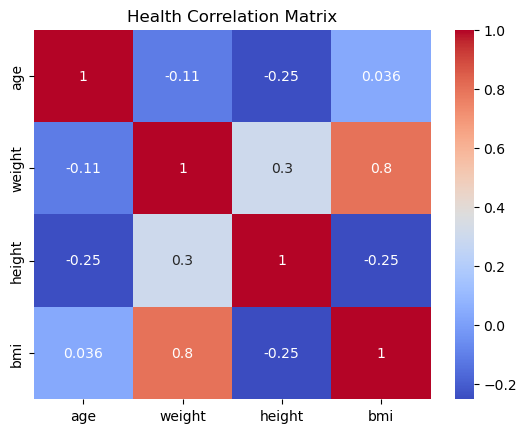

In [25]:
corr = df[['age','weight','height','bmi']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Health Correlation Matrix")
plt.show()

In [26]:
high_risk = df[(df['bmi'] > 30) & (df['age'] > 50)]

high_risk[['given_name','age','bmi']]

,given_name,age,bmi
3,Liêm,74,31.7
7,Xiuxiu,67,30.9
9,Sophie,95,33.4
10,Sandy,51,36.4
11,Abdul-Nur,72,31.5
...,...,...,...
477,Juliusz,59,31.3
479,Tapa,70,36.6
482,Diogo,81,36.6
485,Trifon,53,32.9


In [27]:
df.groupby('state')['bmi'].mean().sort_values(ascending=False)

state
WV            35.833333
MT            34.850000
AR            31.150000
WY            31.100000
KS            31.000000
ID            30.933333
RI            29.775000
AZ            29.250000
California    29.244444
NJ            28.966667
Florida       28.823077
WI            28.600000
AL            28.566667
CO            28.550000
NC            28.450000
GA            28.320000
NM            28.300000
SC            28.280000
FL            28.244444
OR            28.100000
CA            28.095833
MS            28.090000
MD            28.000000
NE            28.000000
MO            27.857143
IA            27.700000
IN            27.566667
MN            27.511111
WA            27.450000
TX            27.253125
PA            27.244444
SD            27.200000
VA            27.127273
TN            26.977778
LA            26.961538
ME            26.950000
New York      26.924000
NY            26.804545
MA            26.636364
IL            26.350000
CT            26.220000
VT        

In [29]:
df.describe(include='all')

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,age,bmi_category,age_group
count,491.000000,491,491,491,491,491,491,491,491,491,491,491.000000,491.000000,491.000000,491.000000,491,491
unique,NaN,2,460,455,483,349,54,430,1,483,NaN,NaN,NaN,NaN,NaN,4,3
top,NaN,male,John,Doe,123 Main Street,New York,California,12345,United States,johndoe@email.com1234567890,NaN,NaN,NaN,NaN,NaN,Normal,Senior
freq,NaN,248,8,6,6,18,36,6,491,6,NaN,NaN,NaN,NaN,NaN,176,290
mean,251.957230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1958-11-23 06:24:11.731160896,173.346640,66.643585,27.460285,66.832994,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1921-11-06 00:00:00,48.800000,27.000000,17.100000,26.000000,NaN,NaN
25%,123.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938-03-25 00:00:00,149.300000,63.000000,23.250000,48.000000,NaN,NaN
50%,252.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1959-03-30 00:00:00,175.600000,67.000000,27.200000,66.000000,NaN,NaN
75%,380.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1978-02-28 12:00:00,199.400000,70.000000,31.650000,87.000000,NaN,NaN
max,503.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-07-03 00:00:00,255.900000,79.000000,37.700000,104.000000,NaN,NaN


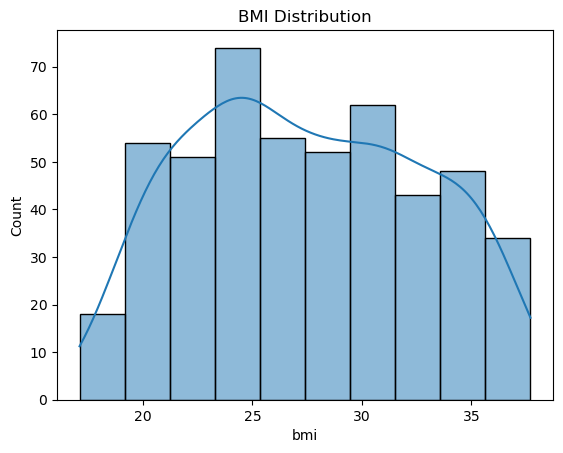

In [30]:
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

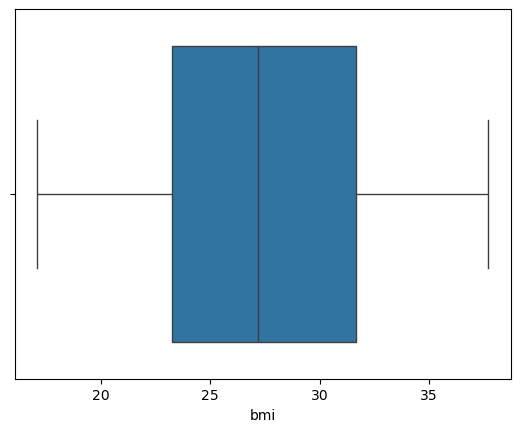

In [31]:
sns.boxplot(x=df['bmi'])
plt.show()

In [36]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['bmi'] < Q1 - 1.5*IQR) |
    (df['bmi'] > Q3 + 1.5*IQR)
]

outliers[['given_name','bmi']]

,given_name,bmi


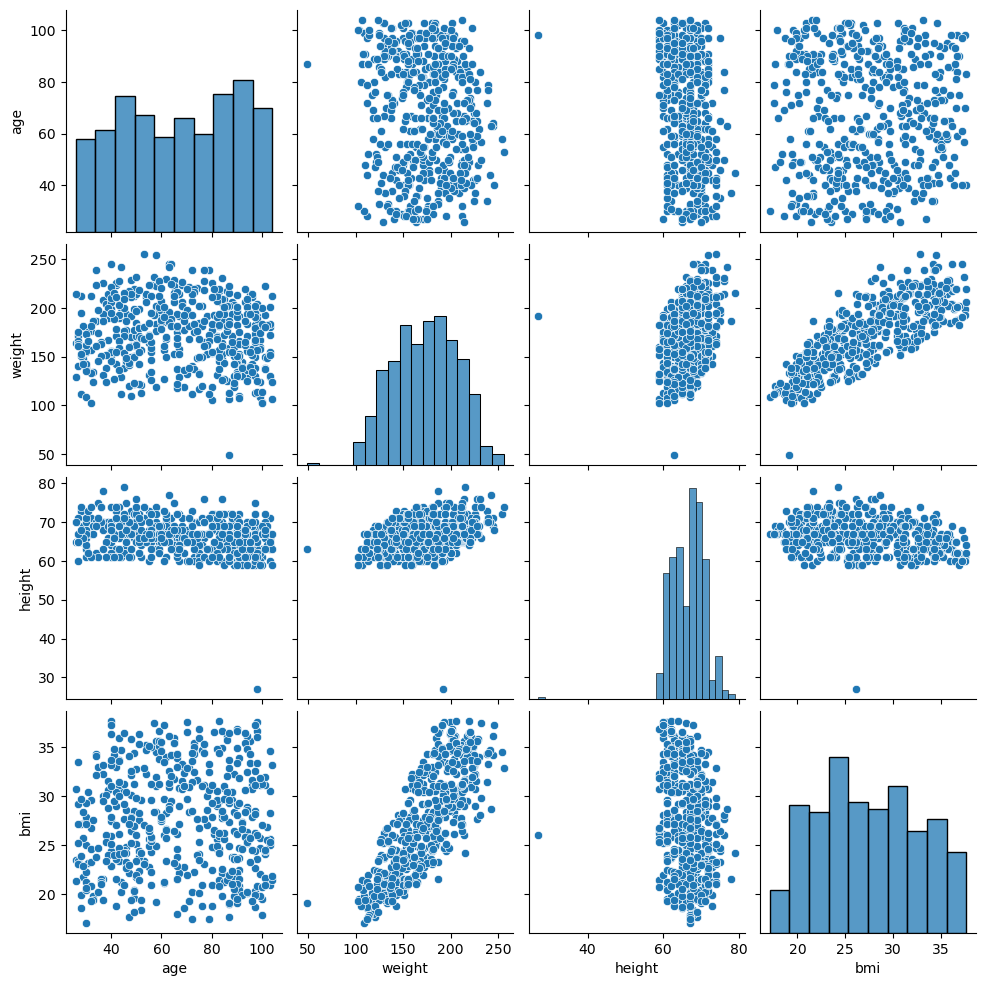

In [37]:
sns.pairplot(df[['age','weight','height','bmi']])

ml pipeline start EDA complete


In [51]:
df['risk'] = (df['bmi'] > 30).astype(int)

df['risk'].value_counts()

risk
0    322
1    169
Name: count, dtype: int64

In [52]:
X = df[['age','weight','height']]
y = df['risk']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
pred = model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.9797979797979798

In [57]:
X = df[['age','assigned_sex','height']]
y = df['risk']

In [58]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[64,  0],
       [ 2, 33]])

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [60]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [62]:
pred = pipeline.predict(X_test)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        64
           1       1.00      0.94      0.97        35

    accuracy                           0.98        99
   macro avg       0.98      0.97      0.98        99
weighted avg       0.98      0.98      0.98        99



In [64]:
import joblib

joblib.dump(pipeline, "health_pipeline.pkl")

['health_pipeline.pkl']

In [65]:
loaded_model = joblib.load("health_pipeline.pkl")

loaded_model.predict([[45,85,170]])

C:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [66]:
new_patient = pd.DataFrame(
    [[45,85,170]],
    columns=['age','weight','height']
)

loaded_model.predict(new_patient)


array([0])

In [67]:


def predict_health_risk(age, weight, height):
    
    patient = pd.DataFrame(
        [[age, weight, height]],
        columns=['age','weight','height']
    )
    
    result = pipeline.predict(patient)[0]
    
    if result == 1:
        print("⚠️ High Health Risk (Obese)")
    else:
        print("✅ Normal Health Risk")

In [68]:
predict_health_risk(45,85,170)

✅ Normal Health Risk
